# National Parks and Local Economies: A Spatial Analysis

This project examines whether rural counties near U.S. national parks are more economically dependent on tourism than urban gateway counties.

Using county-level economic and geographic data, I identify counties within 30 miles of national parks and compare tourism-related employment across rural and urban areas. I then use spatial statistics and regression methods to examine geographic clustering and differences in tourism dependence.

### Methods
- Geospatial data processing with GeoPandas
- Choropleth mapping
- Global Moran's I
- Local Indicators of Spatial Association (LISA)
- OLS and spatial regression

## Data Loading, Cleaning and Inspection

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from splot import esda as esdaplot
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from pysal.model import spreg
import contextily.tile as tile

# Identify application for OpenStreetMap tile requests
tile.USER_AGENT = "AaronWills-NationalParksResearch/1.0"

### National Park Boundaries

National park boundaries were obtained from the National Park Service. The dataset was filtered to include only designated National Parks in the continental United States and Alaska.

In [2]:
#National Park Boundries
parks = gpd.read_file("./data/nps_boundary.geojson")

In [3]:
#Remove Hawaii and US territories 
parks = gpd.read_file("./data/nps_boundary.geojson")

parks = parks[
    (parks["UNIT_TYPE"] == "National Parks") &
    (~parks["STATE"].isin(["HI", "VI", "SA"]))
].copy()

parks.head()

,OBJECTID,UNIT_CODE,GIS_Notes,UNIT_NAME,DATE_EDIT,STATE,REGION,GNIS_ID,UNIT_TYPE,CREATED_BY,...,PARKNAME,CreationDate,Creator,EditDate,Editor,GlobalID,AreaID,Shape__Area,Shape__Length,geometry
5,6,INDU,Lands - http://landsnet.nps.gov/tractsnet/docu...,Indiana Dunes National Park,2025-06-12 07:47:45+00:00,IN,MW,446903,National Parks,Lands,...,Indiana Dunes,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,f9ab9d87-f90a-496b-bcbb-ec362a500fbf,258,0.007071,2.197206,"MULTIPOLYGON (((-86.91850 41.71699, -86.92390 ..."
7,8,NOCA,Lands - http://landsnet.nps.gov/tractsnet/docu...,North Cascades National Park,2024-12-17 00:00:00+00:00,WA,PW,1528421,National Parks,Lands,...,North Cascades,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,3da3f869-1485-4099-862f-5e6bfe6091d7,392,0.247927,4.096577,"MULTIPOLYGON (((-121.23763 49.00066, -121.2595..."
8,9,OLYM,Lands - https://landsnet.nps.gov/tractsnet/doc...,Olympic National Park,2024-12-17 00:00:00+00:00,WA,PW,1530459,National Parks,Lands,...,Olympic,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,fc82b0d0-b330-4827-8ea2-cbd94333b86a,395,0.446293,8.776898,"MULTIPOLYGON (((-123.76512 48.09933, -123.7758..."
9,10,PINN,Lands - http://landsnet.nps.gov/tractsnet/docu...,Pinnacles National Park,2024-12-17 00:00:00+00:00,CA,PW,247533,National Parks,Lands,...,Pinnacles,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,ff9dbb7b-1a8b-4399-aafc-e6d858fb9bb0,349,0.010870,0.767897,"MULTIPOLYGON (((-121.23870 36.54634, -121.2383..."
18,19,VOYA,Lands - http://landsnet.nps.gov/tractsnet/docu...,Voyageurs National Park,2025-02-04 00:00:00+00:00,MN,MW,660491,National Parks,Lands,...,Voyageurs,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,2025-01-14 11:11:09+00:00,NPS_WASO_LANDS,4ab35743-1fc5-4316-a190-8d5de08d6e60,281,0.100693,3.006725,"MULTIPOLYGON (((-92.94973 48.62920, -92.94972 ..."


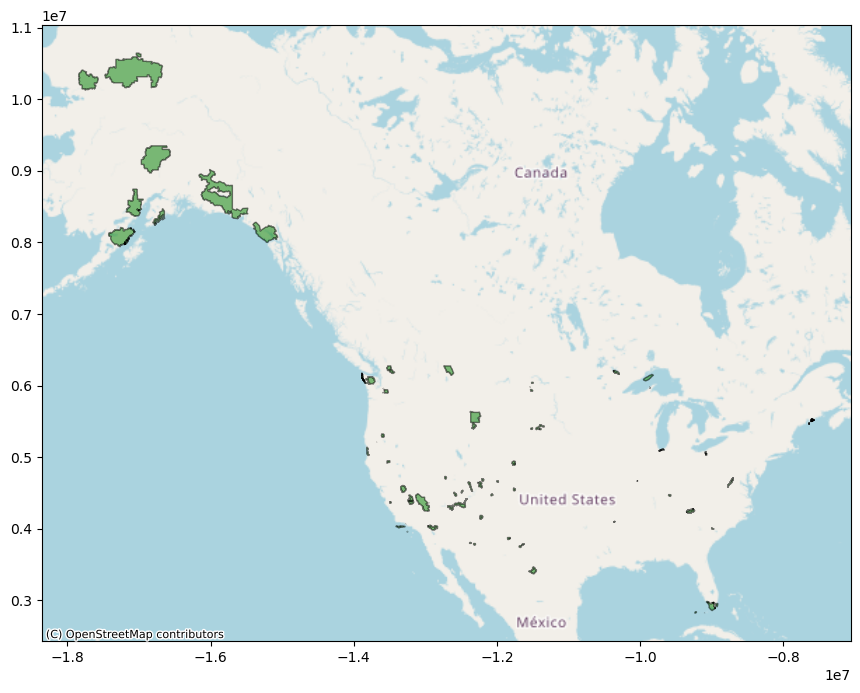

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

parks_webmercator = parks.to_crs(epsg=3857)

parks_webmercator.plot(
    ax=ax,
    alpha=0.5,
    edgecolor="black",
    facecolor="green"
)

cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,
    zoom=3
)

plt.show()

In [39]:
counties = gpd.read_file("./data/tl_2025_us_county.shp")

In [44]:
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,None,None,None,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502...",0
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,None,None,None,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.310 2327435.998, -71100.293 2...",0
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,None,None,None,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.210 1620697.325, 1489336.836...",0
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,None,None,None,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,None,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905...",0


In [45]:
counties = counties.to_crs(epsg=5070)
parks = parks.to_crs(epsg=5070)

### Gateway Counties
Counties within 30 miles of a National Park are classified as gateway counties.

In [46]:
#Narrow Counties to within 30 Miles of a National Park
parks_buffer = parks.buffer(48280)
counties["gateway_30"] = counties.intersects(parks_buffer.unary_union).astype(int)

In [47]:
#Remove Hawaii + US Territories
counties = counties[counties["STATEFP"] != "15"] # Hawaii
counties = counties[counties["STATEFP"] != "72"] # Puero Rico
counties = counties[counties["STATEFP"] != "78"] # Virign Islands
counties = counties[counties["STATEFP"] != "66"] # Guam
counties = counties[counties["STATEFP"] != "60"] #American Samoa
counties = counties[counties["STATEFP"] != "69"] # Northern Mariana Islands

In [81]:
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,None,None,None,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502...",0
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,None,None,None,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.310 2327435.998, -71100.293 2...",0
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,None,None,None,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.210 1620697.325, 1489336.836...",0
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,None,None,None,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,None,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905...",0


In [49]:
df = pd.read_csv("./data/cbp23co.txt")

### Tourism Dependence
Tourism dependence is measured as the share of county employment in tourism-related NAICS industries.

In [50]:
df["GEOID"] = df["fipstate"].astype(str).str.zfill(2) + df["fipscty"].astype(str).str.zfill(3)

In [51]:
df["naics"] = df["naics"].str.strip()

# Create GEOID
df["GEOID"] = df["fipstate"].astype(str).str.zfill(2) + df["fipscty"].astype(str).str.zfill(3)

total = df[df["naics"] == "------"]
total_by_county = total.set_index("GEOID")["emp"]

tourism = df[df["naics"].isin(["71----", "72----"])]
tourism_by_county = tourism.groupby("GEOID")["emp"].sum()

tourism_share = (tourism_by_county / total_by_county).reset_index()
tourism_share.columns = ["GEOID", "tourism_share"]


econ_df = counties.merge(tourism_share, on="GEOID", how="left")

In [82]:
econ_df.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30,tourism_share
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,...,None,None,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502...",0,0.051005
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,...,None,None,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.310 2327435.998, -71100.293 2...",0,0.135398
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,...,None,None,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.210 1620697.325, 1489336.836...",0,0.084249
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,...,None,None,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1,0.357808
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,...,19430,None,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905...",0,0.160600


In [53]:
tourism_share.describe()

,tourism_share
count,3094.000000
mean,0.129881
std,0.073183
min,0.000138
25%,0.089176
50%,0.118083
75%,0.151944
max,0.937957


In [54]:
econ_df.groupby("gateway_30")["tourism_share"].describe()

,count,mean,std,min,25%,50%,75%,max
gateway_30,,,,,,,,
0,2730.0,0.12478,0.065482,0.003205,0.087084,0.115538,0.148094,0.708989
1,353.0,0.17005,0.106642,0.020951,0.112504,0.143064,0.184203,0.937957


In [55]:
rvu_df = pd.read_csv("./data/Ruralurbancontinuumcodes2023.csv", encoding="latin1")
rvu_df.head()

,FIPS,State,County_Name,Attribute,Value
0,1001,AL,Autauga County,Population_2020,58805
1,1001,AL,Autauga County,RUCC_2023,2
2,1001,AL,Autauga County,Description,"Metro - Counties in metro areas of 250,000 to ..."
3,1003,AL,Baldwin County,Population_2020,231767
4,1003,AL,Baldwin County,RUCC_2023,3


In [56]:
rucc_df = rvu_df[rvu_df["Attribute"] == "RUCC_2023"].copy() 
rucc_df["Value"] = rucc_df["Value"].astype(int)
rucc_df["Rural"] = (rucc_df["Value"] >= 4).astype(int) 
rucc_df["GEOID"] = rucc_df["FIPS"].astype(str).str.zfill(5) 
rucc_df

,FIPS,State,County_Name,Attribute,Value,Rural,GEOID
1,1001,AL,Autauga County,RUCC_2023,2,0,01001
4,1003,AL,Baldwin County,RUCC_2023,3,0,01003
7,1005,AL,Barbour County,RUCC_2023,6,1,01005
10,1007,AL,Bibb County,RUCC_2023,1,0,01007
13,1009,AL,Blount County,RUCC_2023,1,0,01009
...,...,...,...,...,...,...,...
9689,72151,PR,Yabucoa Municipio,RUCC_2023,1,0,72151
9692,72153,PR,Yauco Municipio,RUCC_2023,2,0,72153
9695,78010,VI,St. Croix Island,RUCC_2023,5,1,78010
9698,78020,VI,St. John Island,RUCC_2023,9,1,78020


In [57]:
rucc_df["FIPS"] = rucc_df["FIPS"].astype(str).str.zfill(5)

df = econ.merge(
    rucc_df[["FIPS", "Rural"]],
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)
df = df.dropna(subset=['tourism_share']).reset_index(drop=True)


In [58]:
#Combine Rural Codes with other county data
print(len(econ), len(rucc_df))
df.head()

3139 3233


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30,tourism_share,FIPS,Rural
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,...,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502...",0,0.051005,40075,1
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,...,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.310 2327435.998, -71100.293 2...",0,0.135398,46079,1
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,...,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.210 1620697.325, 1489336.836...",0,0.084249,37033,1
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,...,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1,0.357808,48377,1
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,...,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905...",0,0.160600,39057,0


In [60]:
# Gateway's only
gateway = df[df['gateway_30'] == True].copy().reset_index(drop=True)
gateway.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30,tourism_share,FIPS,Rural
0,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,...,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1,0.357808,48377,1
1,47,063,01648576,47063,0500000US47063,Hamblen,Hamblen County,06,H1,G4020,...,A,417476230,37852325,+36.2183967,-083.2660711,"POLYGON ((1131410.292 1546912.445, 1131417.756...",1,0.103396,47063,0
2,08,105,00198168,08105,0500000US08105,Rio Grande,Rio Grande County,06,H1,G4020,...,A,2361956077,984295,+37.4858534,-106.4531280,"POLYGON ((-897663.357 1644178.128, -897718.005...",1,0.158258,08105,1
3,53,033,01531933,53033,0500000US53033,King,King County,06,H1,G4020,...,A,5479767260,496378018,+47.4905518,-121.8339765,"POLYGON ((-1938775.856 3020266.924, -1938643.2...",1,0.111358,53033,0
4,30,073,01719587,30073,0500000US30073,Pondera,Pondera County,06,H1,G4020,...,A,4207608377,43980663,+48.2286037,-112.2207612,"POLYGON ((-1234818.600 2921957.366, -1234808.0...",1,0.152312,30073,1


In [61]:
gateway.groupby("Rural")["tourism_share"].describe()

,count,mean,std,min,25%,50%,75%,max
Rural,,,,,,,,
0,159.0,0.153999,0.086738,0.021277,0.120706,0.139531,0.161133,0.937957
1,194.0,0.183205,0.119149,0.020951,0.107969,0.156812,0.217642,0.747871


Text(0.5, 0, 'Tourism Share')

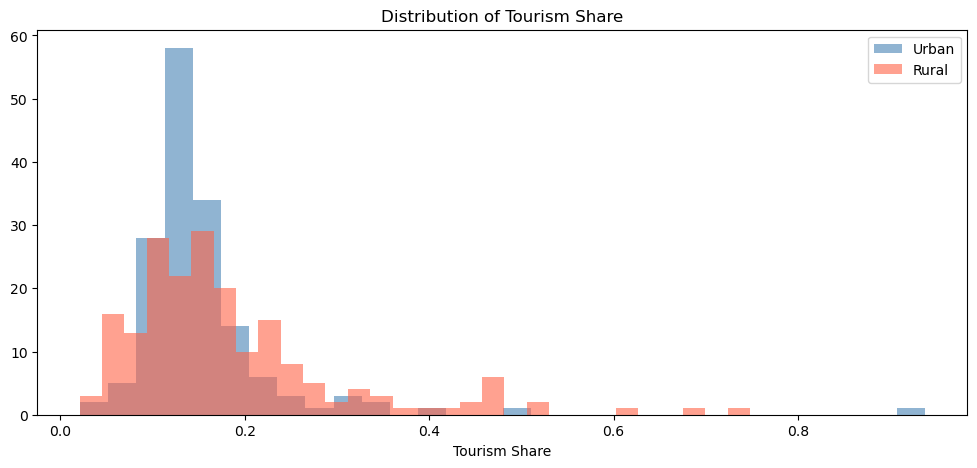

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))


ax.hist(gateway[gateway['Rural'] == 0]['tourism_share'], bins=30, alpha=0.6, label='Urban', color='steelblue')
ax.hist(gateway[gateway['Rural'] == 1]['tourism_share'], bins=30, alpha=0.6, label='Rural', color='tomato')
ax.legend()
ax.set_title('Distribution of Tourism Share')
ax.set_xlabel('Tourism Share')

## Spatial Analysis

#### Choropleth Mapping

In [63]:
np_df = df[df["gateway_30"] == 1] 
np_df.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,gateway_30,tourism_share,FIPS,Rural
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,...,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ...",1,0.357808,48377,1
21,47,063,01648576,47063,0500000US47063,Hamblen,Hamblen County,06,H1,G4020,...,A,417476230,37852325,+36.2183967,-083.2660711,"POLYGON ((1131410.292 1546912.445, 1131417.756...",1,0.103396,47063,0
48,08,105,00198168,08105,0500000US08105,Rio Grande,Rio Grande County,06,H1,G4020,...,A,2361956077,984295,+37.4858534,-106.4531280,"POLYGON ((-897663.357 1644178.128, -897718.005...",1,0.158258,08105,1
51,53,033,01531933,53033,0500000US53033,King,King County,06,H1,G4020,...,A,5479767260,496378018,+47.4905518,-121.8339765,"POLYGON ((-1938775.856 3020266.924, -1938643.2...",1,0.111358,53033,0
63,30,073,01719587,30073,0500000US30073,Pondera,Pondera County,06,H1,G4020,...,A,4207608377,43980663,+48.2286037,-112.2207612,"POLYGON ((-1234818.600 2921957.366, -1234808.0...",1,0.152312,30073,1


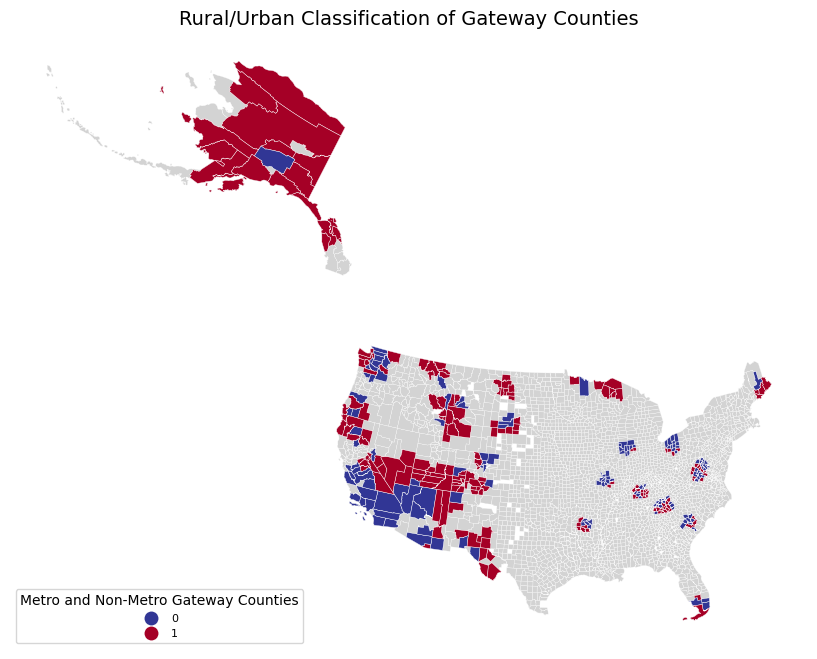

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

#background counties
df.plot(ax=ax, color='lightgrey', linewidth=0.2, edgecolor='white')

gateway = df[df['gateway_30'] == True].copy()

gateway.plot(
    column='Rural',   
    cmap='RdYlBu_r',
    categorical=True,
    linewidth=0.3,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'title': 'Metro and Non-Metro Gateway Counties',
        'loc': 'lower left',
        'fontsize': 8
    },
    ax=ax
)

ax.set_title('Rural/Urban Classification of Gateway Counties', fontsize=14)
ax.set_axis_off()

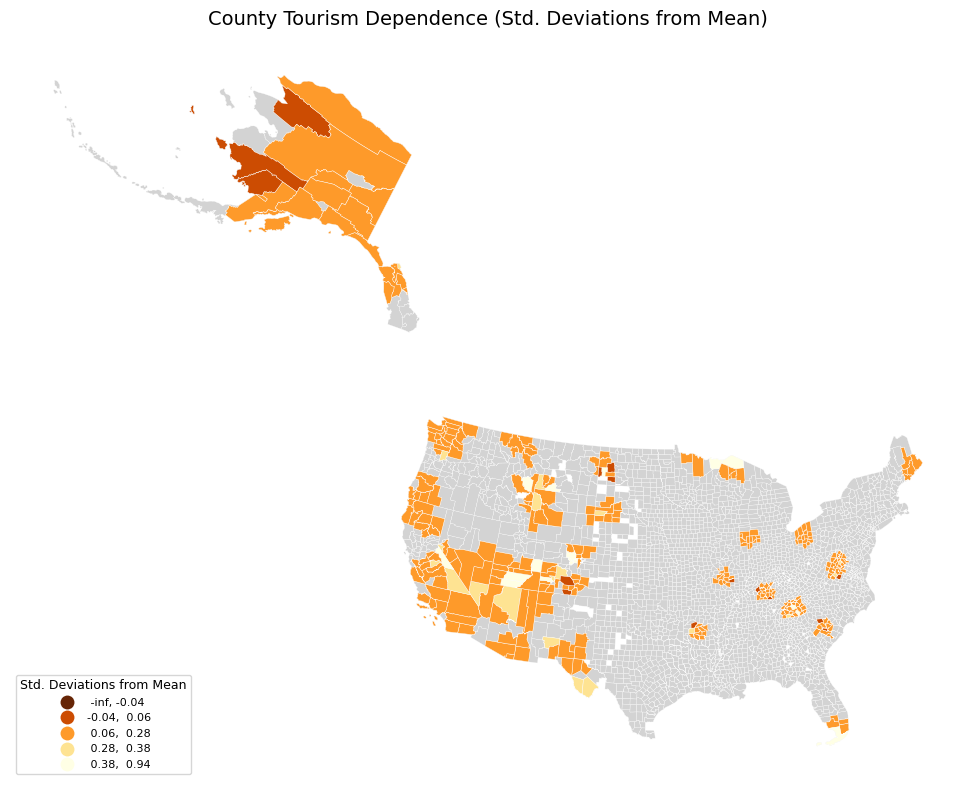

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

#backgroun counties
df.plot(ax=ax, color='lightgrey', linewidth=0.2, edgecolor='white')

np_df.plot(
    column='tourism_share',
    cmap='YlOrBr_r',
    linewidth=0.3,
    edgecolor='white',
    legend=True,
    scheme='StdMean',   
    legend_kwds={
        'title': 'Std. Deviations from Mean',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9,
    },
    ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('County Tourism Dependence (Std. Deviations from Mean)', fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Global Moran's I

In [66]:
# KNN weights
w = KNN.from_dataframe(gateway, k=5)
w.transform = 'r'  

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/libpysal/weights/weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 17 disconnected components.
  warnings.warn(message)


In [68]:
mi = Moran(gateway['tourism_share'], w)

print(f"Moran's I:  {mi.I:.4f}")
print(f"Expected:   {mi.EI:.4f}")
print(f"p-value:    {mi.p_sim:.4f}")
print(f"z-score:    {mi.z_sim:.4f}")

Moran's I:  0.2189
Expected:   -0.0028
p-value:    0.0010
z-score:    7.0739


## LISA

In [69]:
lisa = Moran_Local(gateway['tourism_share'], w)

gateway['lisa_p'] = lisa.p_sim
gateway['lisa_q'] = lisa.q  # quadrant: 1=HH, 2=LH, 3=LL, 4=HL
gateway['lisa_significant'] = lisa.p_sim < 0.05

cluster_labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
gateway['lisa_cluster'] = gateway.apply(
    lambda row: cluster_labels[row['lisa_q']] if row['lisa_significant'] else 'NS',
    axis=1
)

print(gateway['lisa_cluster'].value_counts())

lisa_cluster
NS    279
LL     34
HH     22
LH     17
HL      1
Name: count, dtype: int64


(<Figure size 1400x800 with 1 Axes>, <Axes: >)

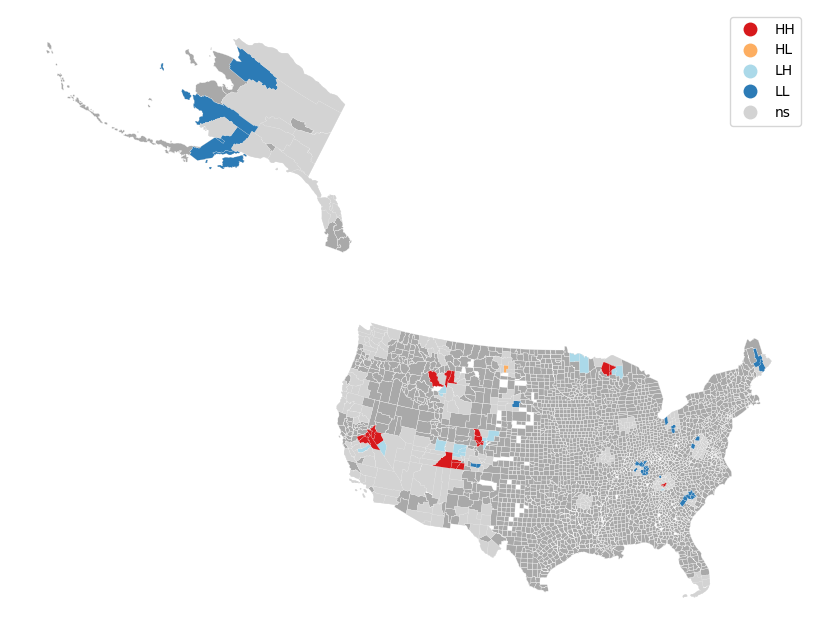

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
df.plot(ax=ax, color='darkgrey', linewidth=0.2, edgecolor='white')

esdaplot.lisa_cluster(lisa, gateway, p=0.05, ax=ax)

In [75]:
# What share of HH clusters are rural vs urban?
hh_counties = gateway[gateway['lisa_cluster'] == 'HH']
print(hh_counties['Rural'].value_counts(normalize=True))

# Compare to overall gateway composition
print(gateway['Rural'].value_counts(normalize=True)) 

Rural
1    0.818182
0    0.181818
Name: proportion, dtype: float64
Rural
1    0.549575
0    0.450425
Name: proportion, dtype: float64


# Spatial Regression

In [76]:
from pysal.model import spreg
from spreg import ML_Lag, ML_Error

In [77]:
variable_names = ['Rural']

m_ols = spreg.OLS(
    gateway[['tourism_share']].values,
    gateway[variable_names].values,
    w=w,
    spat_diag=True,
    name_y='tourism_share',
    name_x=variable_names,
    name_w='knn5'
)
print(m_ols.summary)


REGRESSION
----------
SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        knn5
Dependent Variable  :tourism_share                Number of Observations:         353
Mean dependent var  :      0.1700                Number of Variables   :           2
S.D. dependent var  :      0.1066                Degrees of Freedom    :         351
R-squared           :      0.0186
Adjusted R-squared  :      0.0158
Sum squared residual:       3.929                F-statistic           :      6.6596
Sigma-square        :       0.011                Prob(F-statistic)     :     0.01027
S.E. of regression  :       0.106                Log likelihood        :     293.044
Sigma-square ML     :       0.011                Akaike info criterion :    -582.088
S.E of regression ML:      0.1055                Schwarz criterion     :    -574.355

----------------------------------------------------------------------------

In [78]:
gateway['ols_residuals'] = m_ols.u
mi_resid = Moran(gateway['ols_residuals'], w)
print(f"Residual Moran's I: {mi_resid.I:.4f}")
print(f"p-value:            {mi_resid.p_sim:.4f}")

Residual Moran's I: 0.2055
p-value:            0.0010


In [79]:
m_error = spreg.ML_Error(
    gateway[['tourism_share']].values,
    gateway[variable_names].values,
    w=w,
    name_y='tourism_share',
    name_x=variable_names,
    name_w='knn5'
)

print(m_error.summary) 

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/scipy/optimize/_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


REGRESSION
----------
SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL ERROR (METHOD = FULL)
-------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        knn5
Dependent Variable  :tourism_share                Number of Observations:         353
Mean dependent var  :      0.1700                Number of Variables   :           2
S.D. dependent var  :      0.1066                Degrees of Freedom    :         351
Pseudo R-squared    :      0.0186
Sigma-square ML     :       0.010                Log likelihood        :     307.238
S.E of regression   :       0.100                Akaike info criterion :    -610.476
                                                 Schwarz criterion     :    -602.743

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------------------------------

In [80]:
m_regimes = spreg.OLS_Regimes(
    gateway[['tourism_share']].values,
    gateway[variable_names].values,
    gateway['Rural'].tolist(),
    name_y='tourism_share',
    name_x=variable_names,
    name_regimes='Rural',
    w=w,
    spat_diag=True
)

print(m_regimes.summary)
print("Chow test:", m_regimes.chow.joint)

REGRESSION
----------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES ESTIMATION - REGIME 0
---------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :0_tourism_share                Number of Observations:         159
Mean dependent var  :      0.1540                Number of Variables   :           1
S.D. dependent var  :      0.0867                Degrees of Freedom    :         158
R-squared           :      0.0000
Adjusted R-squared  :      0.0000
Sum squared residual:       1.189                F-statistic           :         inf
Sigma-square        :       0.008                Prob(F-statistic)     :         nan
S.E. of regression  :       0.087                Log likelihood        :     163.624
Sigma-square ML     :       0.007                Akaike info criterion :    -325.248
S.E of regression ML:      0.0865                Schwarz criterion     :    -322.179

-----------------------------

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/spreg/diagnostics.py:96: RuntimeWarning: divide by zero encountered in double_scalars
  fStat = (U / (k - 1)) / (Q / (n - k))
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/spreg/diagnostics.py:96: RuntimeWarning: invalid value encountered in double_scalars
  fStat = (U / (k - 1)) / (Q / (n - k))
